In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../dev_data_30.csv")

In [41]:
df["Date"] = pd.to_datetime(df["Date"])
df["Volume"] = (
    df["Volume"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

price_cols = ["Open", "High", "Low", "Close", "Adj. Close"]
for col in price_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

/var/folders/zn/5xx6pq_x6mbdlcfj06k504l00000gn/T/ipykernel_84579/3694296273.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [42]:
print(df.head())
print(df.dtypes)
print(df.shape)
print(df["Ticker"].nunique(), "tickers")
print(df["Date"].min(), df["Date"].max())
print(df.isna().sum())

  Ticker       Date  Open  High   Low  Close  Adj. Close     Volume
0      A 2017-03-15  6.70  6.77  5.96   6.06        6.06  6970100.0
1      A 2017-03-16  6.10  6.20  5.75   5.76        5.76  3652400.0
2      A 2017-03-17  5.81  5.89  5.65   5.80        5.80  3477100.0
3      A 2017-03-20  5.85  5.86  5.51   5.57        5.57  2484100.0
4      A 2017-03-21  5.56  5.60  5.42   5.46        5.46  1798400.0
Ticker                   str
Date          datetime64[us]
Open                 float64
High                 float64
Low                  float64
Close                float64
Adj. Close           float64
Volume               float64
dtype: object
(30180, 8)
30 tickers
2017-03-15 00:00:00 2021-03-12 00:00:00
Ticker        0
Date          0
Open          0
High          0
Low           0
Close         0
Adj. Close    0
Volume        0
dtype: int64


In [43]:
close = df.pivot(index="Date", columns="Ticker", values="Adj. Close")
open_ = df.pivot(index="Date", columns="Ticker", values="Open")
high = df.pivot(index="Date", columns="Ticker", values="High")
low = df.pivot(index="Date", columns="Ticker", values="Low")
volume = df.pivot(index="Date", columns="Ticker", values="Volume")

In [44]:
## Daily Returns
ret = close.pct_change()
log_ret = np.log(close / close.shift(1))

# Basic Return Diagnostics

In [45]:
summary = pd.DataFrame({
    "mean": ret.mean(),
    "std": ret.std(),
    "min": ret.min(),
    "max": ret.max(),
    "skew": ret.skew(),
    "kurt": ret.kurt()
})
print(summary)

            mean       std       min       max      skew       kurt
Ticker                                                             
A       0.003346  0.050226 -0.400000  0.357424  0.357286   8.303398
AA      0.000849  0.017325 -0.151632  0.122221  0.119441  13.085903
AB      0.000664  0.017723 -0.110056  0.204104  1.119316  24.756260
AC      0.000646  0.018250 -0.111953  0.133694 -0.225351   9.714764
AD      0.001648  0.020188 -0.140231  0.126560  0.022337   5.512352
B       0.001974  0.029483 -0.184096  0.121087 -0.307070   3.814786
C       0.001610  0.038095 -0.186170  0.415005  2.354104  23.868379
D       0.001199  0.055094 -0.457423  0.765914  3.303748  56.783927
E       0.000499  0.020324 -0.188867  0.114023 -1.170497  12.679962
F       0.000514  0.032088 -0.195378  0.370262  2.056509  25.066718
G       0.001583  0.026659 -0.134963  0.171865  0.354093   7.086163
H       0.000751  0.028027 -0.217991  0.170354 -0.254906  13.132389
I       0.000574  0.020961 -0.133081  0.160607  

<Axes: xlabel='Date'>

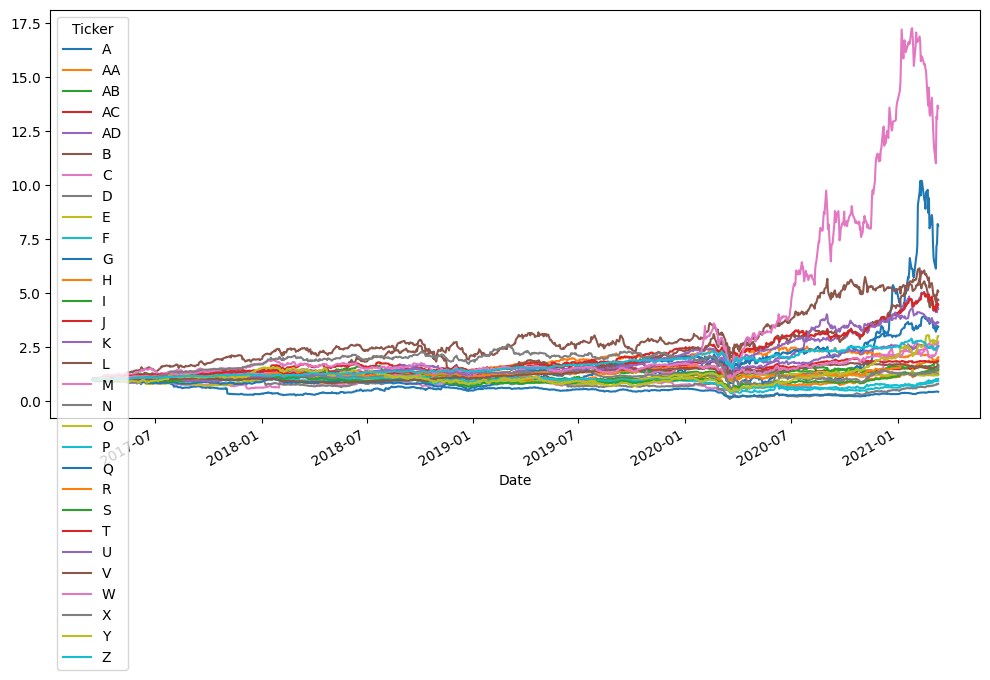

In [46]:
cum_ret = (1 + ret).cumprod()
cum_ret.plot(figsize=(12, 6))

<Axes: xlabel='Date'>

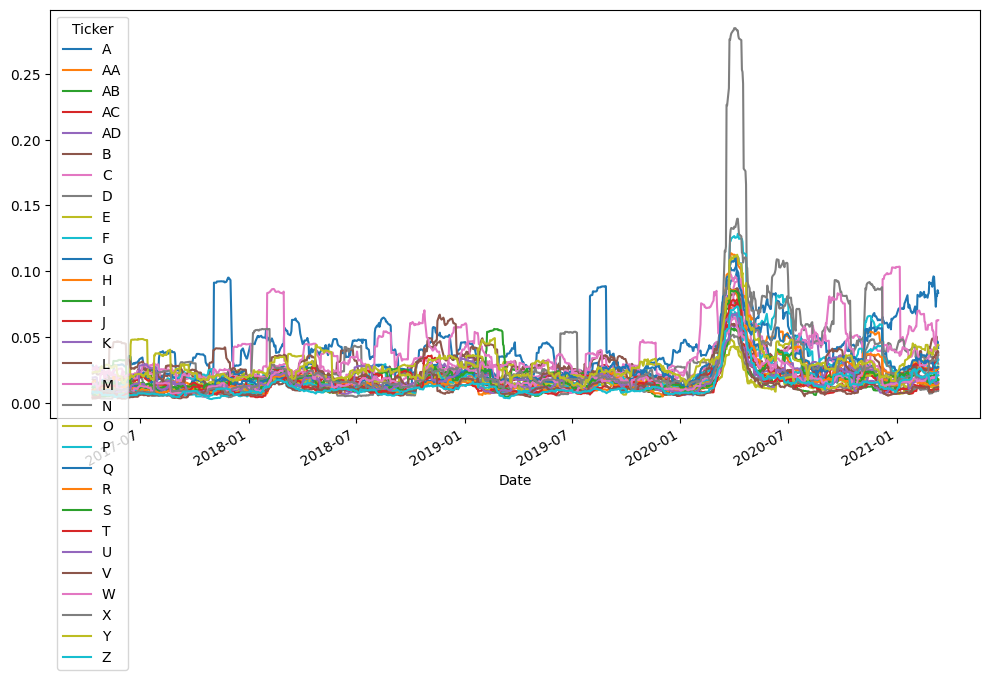

In [47]:
rolling_vol = ret.rolling(20).std()
rolling_vol.plot(figsize=(12, 6))

In [48]:
acf_summary = pd.DataFrame({
    "lag1": [ret[c].autocorr(lag=1) for c in ret.columns],
    "lag5": [ret[c].autocorr(lag=5) for c in ret.columns],
    "lag20": [ret[c].autocorr(lag=20) for c in ret.columns],
}, index=ret.columns)

print(acf_summary)

# positive = returns tend to continue -> momentum
# negative = returns tend to reverse -> means reversion

            lag1      lag5     lag20
Ticker                              
A       0.021248  0.005757  0.022289
AA     -0.167526  0.098080 -0.101763
AB     -0.225719  0.082696 -0.052878
AC     -0.180542  0.001230 -0.061786
AD     -0.210373  0.067281 -0.032953
B      -0.117976  0.033942 -0.033148
C      -0.007919  0.002814 -0.039533
D      -0.017888 -0.002526  0.005455
E       0.035967 -0.094619  0.049447
F       0.141651 -0.093846 -0.033172
G      -0.202682  0.055100 -0.010403
H      -0.139167  0.123975  0.041045
I      -0.120464 -0.033087 -0.065803
J      -0.183435  0.012858 -0.046392
K      -0.140696  0.035363 -0.063767
L      -0.140920 -0.002168 -0.010750
M      -0.008432 -0.042440 -0.005235
N      -0.102143  0.003485 -0.067947
O      -0.066369  0.040158 -0.031506
P      -0.057404  0.116099  0.013004
Q      -0.031774  0.034975  0.035228
R      -0.189098  0.102309 -0.040157
S      -0.151875  0.006613 -0.035653
T      -0.188337  0.055928 -0.030080
U      -0.068809  0.045686 -0.019624
V

In [49]:
sq_ret = ret ** 2

sq_acf_summary = pd.DataFrame({
    "lag1": [sq_ret[c].autocorr(lag=1) for c in sq_ret.columns],
    "lag5": [sq_ret[c].autocorr(lag=5) for c in sq_ret.columns],
    "lag20": [sq_ret[c].autocorr(lag=20) for c in sq_ret.columns],
}, index=sq_ret.columns)

print(sq_acf_summary)

# positive = volatility regime stays low or high

            lag1      lag5     lag20
Ticker                              
A       0.052932 -0.000142  0.020684
AA      0.570239  0.387865  0.066266
AB      0.455265  0.072118 -0.002808
AC      0.421563  0.141282  0.070139
AD      0.476247  0.126142  0.047719
B       0.298257  0.216869  0.034617
C       0.029621  0.003644  0.002843
D       0.146804  0.134928  0.005596
E       0.194305  0.005696 -0.018862
F       0.261200  0.156516  0.055116
G       0.333650  0.300501  0.085527
H       0.287721  0.370794  0.143423
I       0.122865  0.081836  0.017320
J       0.270535  0.209918  0.100604
K       0.326646  0.230726  0.095542
L       0.271642  0.121639  0.079715
M       0.189847  0.115919 -0.005408
N       0.372020  0.255736  0.078597
O       0.137786  0.067150  0.006509
P       0.211222  0.272913  0.102981
Q       0.180821  0.225249  0.092876
R       0.458602  0.281229  0.087723
S       0.469679  0.224935  0.050503
T       0.152380  0.165530  0.060666
U       0.267506  0.117417  0.048712
V

In [50]:
corr = ret.corr()
print(corr)

Ticker         A        AA        AB        AC        AD         B         C  \
Ticker                                                                         
A       1.000000  0.192336  0.213772  0.271343  0.300766  0.311699  0.159017   
AA      0.192336  1.000000  0.418988  0.419065  0.319215  0.301478  0.099537   
AB      0.213772  0.418988  1.000000  0.613470  0.426933  0.366702  0.081845   
AC      0.271343  0.419065  0.613470  1.000000  0.486667  0.426053  0.164827   
AD      0.300766  0.319215  0.426933  0.486667  1.000000  0.424029  0.171448   
B       0.311699  0.301478  0.366702  0.426053  0.424029  1.000000  0.213884   
C       0.159017  0.099537  0.081845  0.164827  0.171448  0.213884  1.000000   
D       0.256606  0.159776  0.197998  0.287581  0.249780  0.386045  0.171715   
E       0.073657  0.113611  0.165703  0.206285  0.091718  0.111932  0.119798   
F       0.256880  0.142829  0.219911  0.324720  0.217452  0.308105  0.120070   
G       0.360756  0.412337  0.499022  0.

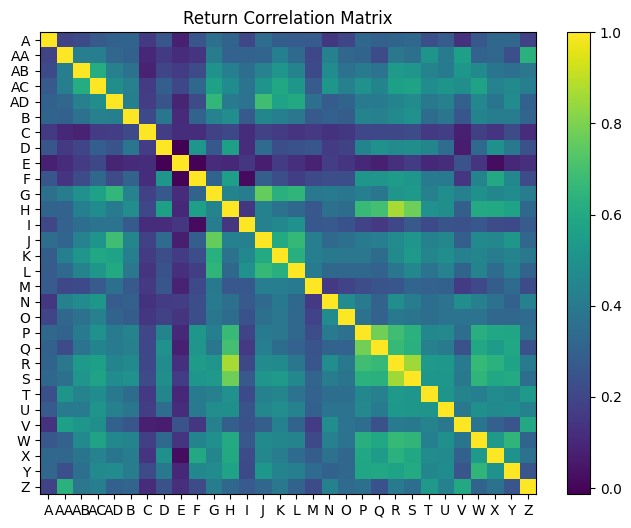

In [51]:
plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Return Correlation Matrix")
plt.show()

<Axes: title={'center': 'Rolling 60-Day Correlation: A vs F'}, xlabel='Date'>

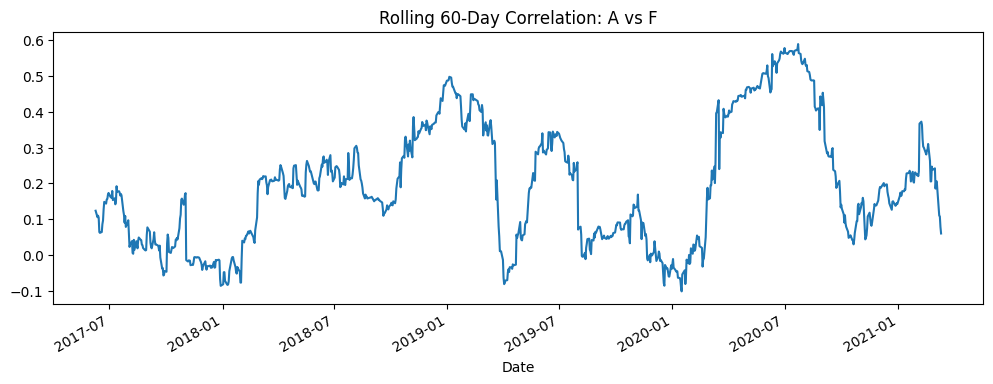

In [52]:
rolling_corr_AF = ret["A"].rolling(60).corr(ret["F"])
rolling_corr_AF.plot(figsize=(12, 4), title="Rolling 60-Day Correlation: A vs F")

<Axes: title={'center': 'Drawdown: A'}, xlabel='Date'>

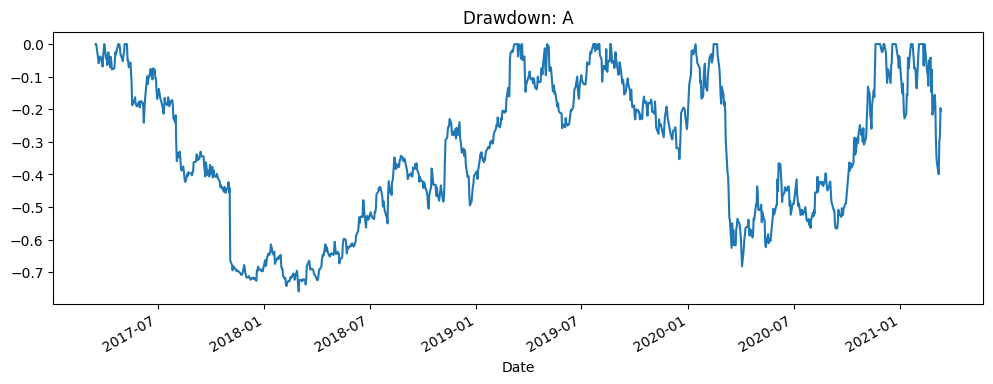

In [53]:
cum = (1 + ret["A"]).cumprod()
running_max = cum.cummax()
drawdown = cum / running_max - 1
drawdown.plot(figsize=(12, 4), title="Drawdown: A")